In [1]:
from dotenv import load_dotenv
import os
import boto3
import awswrangler as wr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np

load_dotenv()

# ── Config ──────────────────────────────────────────────────────────
S3_OUTPUT = "s3://pharma-bi-raw/athena-results/"
DATABASE  = "pharma_bi_db"

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

def run_query(sql: str) -> pd.DataFrame:
    """Run an Athena SQL query and return a pandas DataFrame."""
    return wr.athena.read_sql_query(
        sql=sql,
        database=DATABASE,
        s3_output=S3_OUTPUT,
        boto3_session=session
    )

# ── Plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'sans-serif',
})

BRANDED_COLOR = '#2C6FAC'
GENERIC_COLOR = '#E07B3A'

# ── Sanity check ────────────────────────────────────────────────────
df_check = run_query("SELECT COUNT(*) AS n FROM fact_sales")
print(f"Connection OK — {df_check['n'].iloc[0]:,} rows in FactSales")

Connection OK — 62,139 rows in FactSales


In [2]:
query_overall = """
SELECT
    dpr.isgeneric,
    COUNT(DISTINCT dpr.productid)                           AS product_count,
    COUNT(fs.salesid)                                       AS transactions,
    SUM(fs.unitssold)                                       AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                             AS total_margin,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue_per_tx,
    ROUND(AVG(fs.margineur), 2)                             AS avg_margin_per_tx,
    ROUND(AVG(CAST(fs.unitssold AS DOUBLE)), 2)             AS avg_units_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(fs.unitssold), 2)       AS revenue_per_unit,
    ROUND(COUNT(fs.salesid) * 100.0 / SUM(COUNT(fs.salesid)) OVER (), 1) AS tx_share_pct,
    ROUND(SUM(fs.revenueeur) * 100.0 / SUM(SUM(fs.revenueeur)) OVER (), 1) AS revenue_share_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.isgeneric
ORDER BY dpr.isgeneric
"""

df_overall = run_query(query_overall)
df_overall['label'] = df_overall['isgeneric'].map({'No': 'Branded', 'Yes': 'Generic'})
print(df_overall.to_string(index=False))


isgeneric  product_count  transactions  total_units  total_revenue  total_margin  avg_revenue_per_tx  avg_margin_per_tx  avg_units_per_tx  margin_pct  revenue_per_unit  tx_share_pct  revenue_share_pct   label
       No            187         52302       371106     7373585.94    2100014.93              140.98              40.15              7.10        28.5             19.87          84.2               85.4 Branded
      Yes             33          9837        74687     1260391.37     321126.14              128.13              32.64              7.59        25.5             16.88          15.8               14.6 Generic


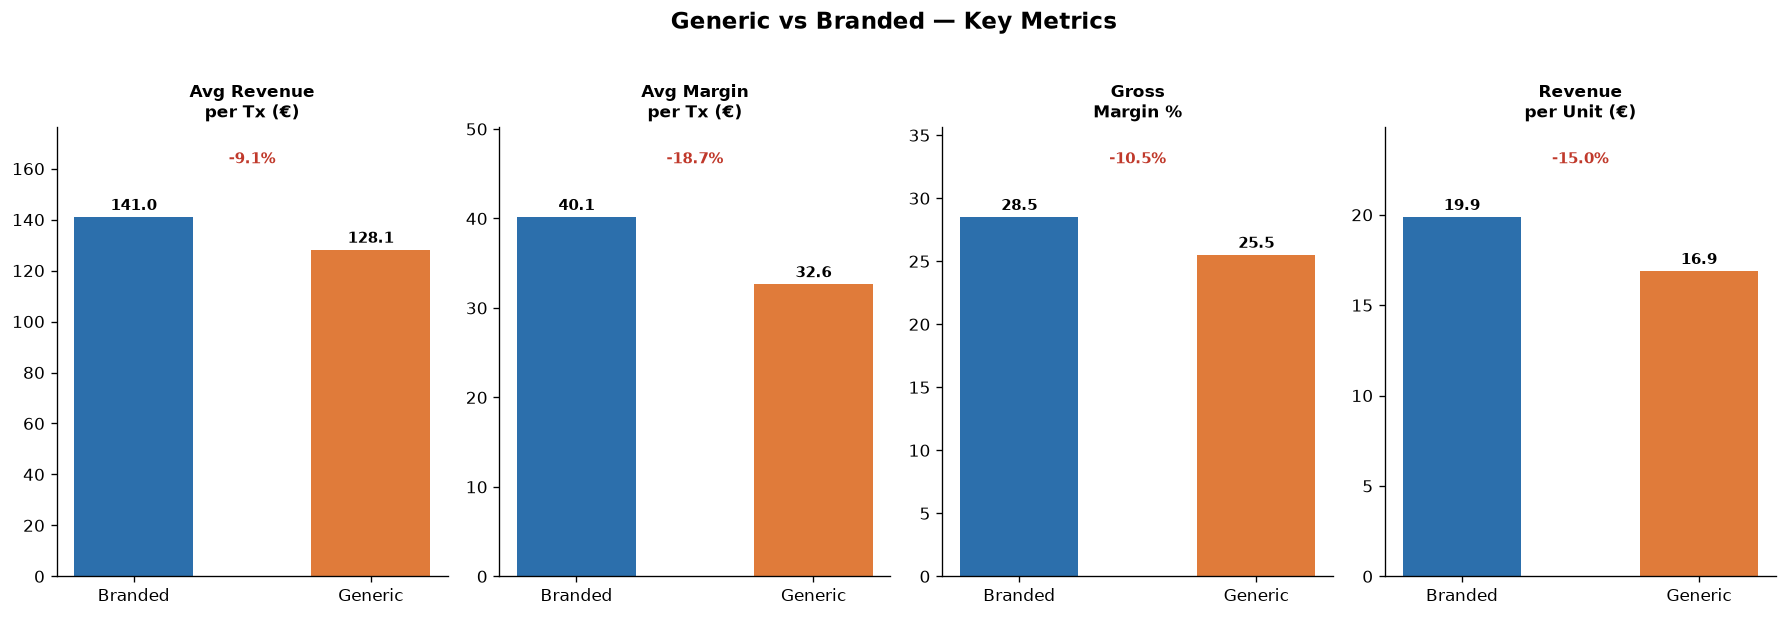

In [3]:
# Four-panel comparison chart
metrics = ['avg_revenue_per_tx', 'avg_margin_per_tx', 'margin_pct', 'revenue_per_unit']
titles  = ['Avg Revenue\nper Tx (€)', 'Avg Margin\nper Tx (€)', 'Gross\nMargin %', 'Revenue\nper Unit (€)']

branded = df_overall[df_overall['isgeneric'] == 'No'].iloc[0]
generic = df_overall[df_overall['isgeneric'] == 'Yes'].iloc[0]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, metric, title in zip(axes, metrics, titles):
    vals   = [branded[metric], generic[metric]]
    colors = [BRANDED_COLOR, GENERIC_COLOR]
    bars   = ax.bar(['Branded', 'Generic'], vals, color=colors, width=0.5)
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, max(vals) * 1.25)

    # Value labels
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f'{v:.1f}',
            ha='center', fontsize=9, fontweight='bold'
        )

    # Difference annotation on each chart
    diff_pct = (vals[1] - vals[0]) / vals[0] * 100
    axes_color = '#C0392B' if diff_pct < 0 else '#3A9E6F'
    ax.text(
        0.5, 0.92, f'{diff_pct:+.1f}%',
        ha='center', transform=ax.transAxes,
        fontsize=9, color=axes_color, fontweight='bold'
    )

plt.suptitle('Generic vs Branded — Key Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/01_generic_vs_branded_overall.png', bbox_inches='tight')
plt.show()

In [4]:
query_cat = """
SELECT
    dpr.category,
    dpr.isgeneric,
    COUNT(DISTINCT dpr.productid)                           AS product_count,
    COUNT(fs.salesid)                                       AS transactions,
    SUM(fs.unitssold)                                       AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue_per_tx,
    ROUND(AVG(CAST(fs.unitssold AS DOUBLE)), 2)             AS avg_units_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(fs.unitssold), 2)        AS revenue_per_unit
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
WHERE dpr.category IN ('OTC', 'Prescription')
GROUP BY dpr.category, dpr.isgeneric
ORDER BY dpr.category, dpr.isgeneric
"""

df_cat = run_query(query_cat)
df_cat['label'] = df_cat['isgeneric'].map({'No': 'Branded', 'Yes': 'Generic'})
print(df_cat.to_string(index=False))


    category isgeneric  product_count  transactions  total_units  total_revenue  avg_revenue_per_tx  avg_units_per_tx  margin_pct  revenue_per_unit   label
         OTC        No             41         13105       120027     1223425.85               93.36              9.16        29.5             10.19 Branded
         OTC       Yes             20          6307        57659      573903.70               90.99              9.14        29.2              9.95 Generic
Prescription        No             34          9590        46249     2110528.09              220.08              4.82        21.8             45.63 Branded
Prescription       Yes             13          3530        17028      686487.67              194.47              4.82        22.4             40.32 Generic


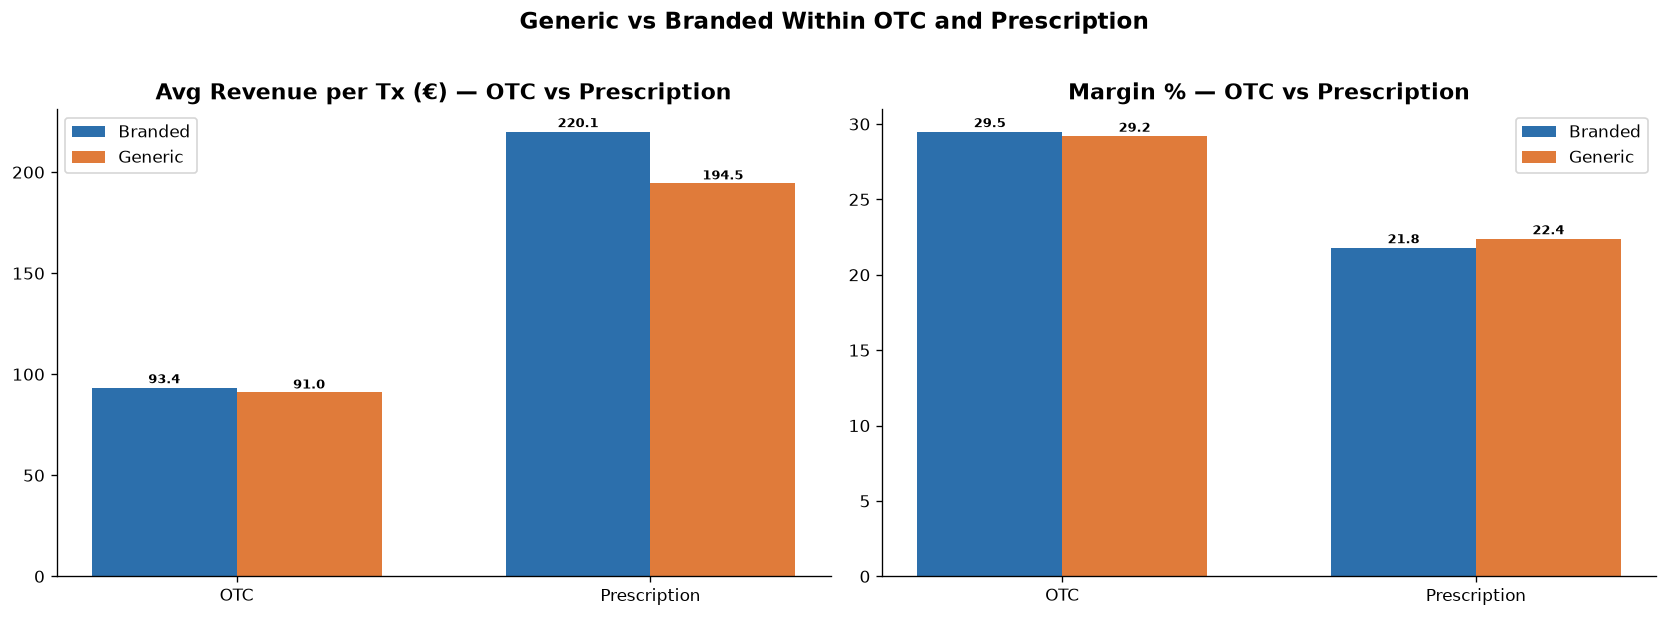

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['OTC', 'Prescription']
metrics_cat = ['avg_revenue_per_tx', 'margin_pct']
titles_cat  = ['Avg Revenue per Tx (€)', 'Margin %']

for ax, metric, title in zip(axes, metrics_cat, titles_cat):
    x = np.arange(len(categories))
    w = 0.35

    for i, (gen_val, label, color) in enumerate(zip(['No', 'Yes'], ['Branded', 'Generic'],
                                                     [BRANDED_COLOR, GENERIC_COLOR])):
        vals = [
            df_cat[(df_cat['category'] == cat) & (df_cat['isgeneric'] == gen_val)][metric].values
            for cat in categories
        ]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]
        offset = (i - 0.5) * w
        bars = ax.bar(x + offset, vals, width=w, label=label, color=color)

        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.01,
                    f'{v:.1f}',
                    ha='center', fontsize=8, fontweight='bold'
                )

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_title(f'{title} — OTC vs Prescription', fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Generic vs Branded Within OTC and Prescription', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/02_generic_branded_by_category.png', bbox_inches='tight')
plt.show()

In [6]:
query_penetration = """
SELECT
    category,
    SUM(CASE WHEN isgeneric = 'No'  THEN 1 ELSE 0 END) AS branded_products,
    SUM(CASE WHEN isgeneric = 'Yes' THEN 1 ELSE 0 END) AS generic_products,
    COUNT(*)                                             AS total_products,
    ROUND(
        SUM(CASE WHEN isgeneric = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
    1) AS generic_penetration_pct
FROM dim_product
GROUP BY category
ORDER BY generic_penetration_pct DESC
"""

df_pen = run_query(query_penetration)
print(df_pen.to_string(index=False))


       category  branded_products  generic_products  total_products  generic_penetration_pct
            OTC                41                20              61                     32.8
   Prescription                34                13              47                     27.7
       Wellness                41                 0              41                      0.0
Medical Devices                24                 0              24                      0.0
  Personal Care                47                 0              47                      0.0


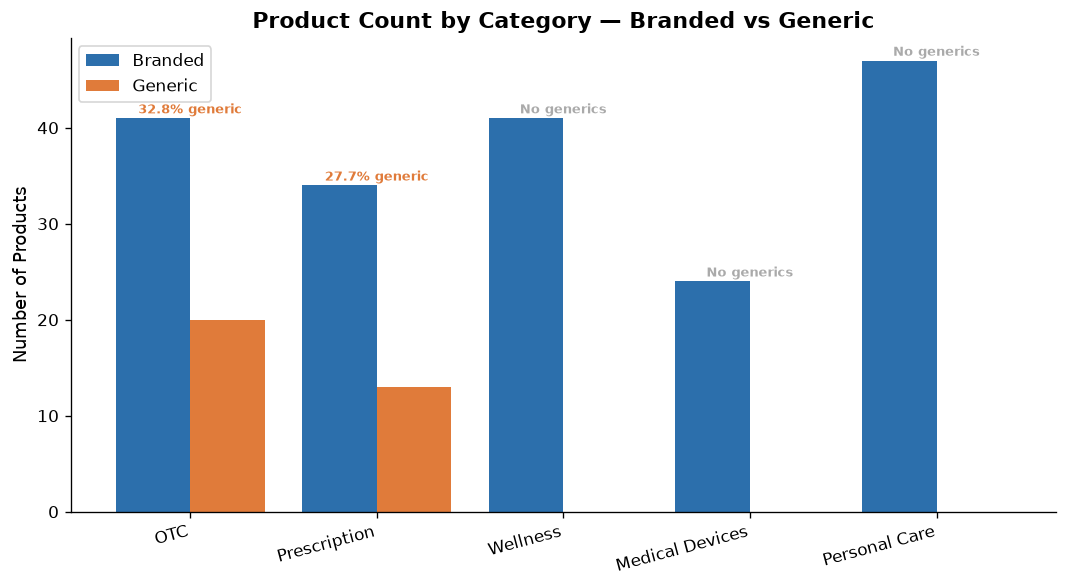

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(df_pen))
w = 0.4

ax.bar(x - w/2, df_pen['branded_products'], width=w, label='Branded', color=BRANDED_COLOR)
ax.bar(x + w/2, df_pen['generic_products'],  width=w, label='Generic',  color=GENERIC_COLOR)

ax.set_xticks(x)
ax.set_xticklabels(df_pen['category'], rotation=15, ha='right')
ax.set_ylabel('Number of Products')
ax.set_title('Product Count by Category — Branded vs Generic', fontweight='bold')
ax.legend()

# Annotate generic penetration % above each pair
for i, pct in enumerate(df_pen['generic_penetration_pct']):
    label = f'{pct}% generic' if pct > 0 else 'No generics'
    color = GENERIC_COLOR if pct > 0 else '#aaa'
    ax.text(i, df_pen[['branded_products','generic_products']].max(axis=1).iloc[i] + 0.5,
            label, ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/03_generic_penetration_by_category.png', bbox_inches='tight')
plt.show()

In [8]:
query_country = """
SELECT
    dp.country,
    ROUND(SUM(CASE WHEN dpr.isgeneric = 'No'  THEN fs.revenueeur ELSE 0 END), 2) AS branded_revenue,
    ROUND(SUM(CASE WHEN dpr.isgeneric = 'Yes' THEN fs.revenueeur ELSE 0 END), 2) AS generic_revenue,
    ROUND(
        SUM(CASE WHEN dpr.isgeneric = 'Yes' THEN fs.revenueeur ELSE 0 END) * 100.0
        / SUM(fs.revenueeur),
    1) AS generic_share_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid  = dpr.productid
JOIN dim_pharmacy dp  ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.country
ORDER BY generic_share_pct DESC
"""

df_country = run_query(query_country)
print(df_country.to_string(index=False))


    country  branded_revenue  generic_revenue  generic_share_pct
Netherlands        806530.27        141217.93               14.9
    Belgium       1061390.90        185119.87               14.9
     Poland        607572.57        106663.16               14.9
     France       1198677.29        208134.45               14.8
    Austria        583821.52         99459.65               14.6
      Spain        629149.43        106450.81               14.5
    Germany       1342206.20        225427.75               14.4
      Italy       1144237.76        187917.75               14.1


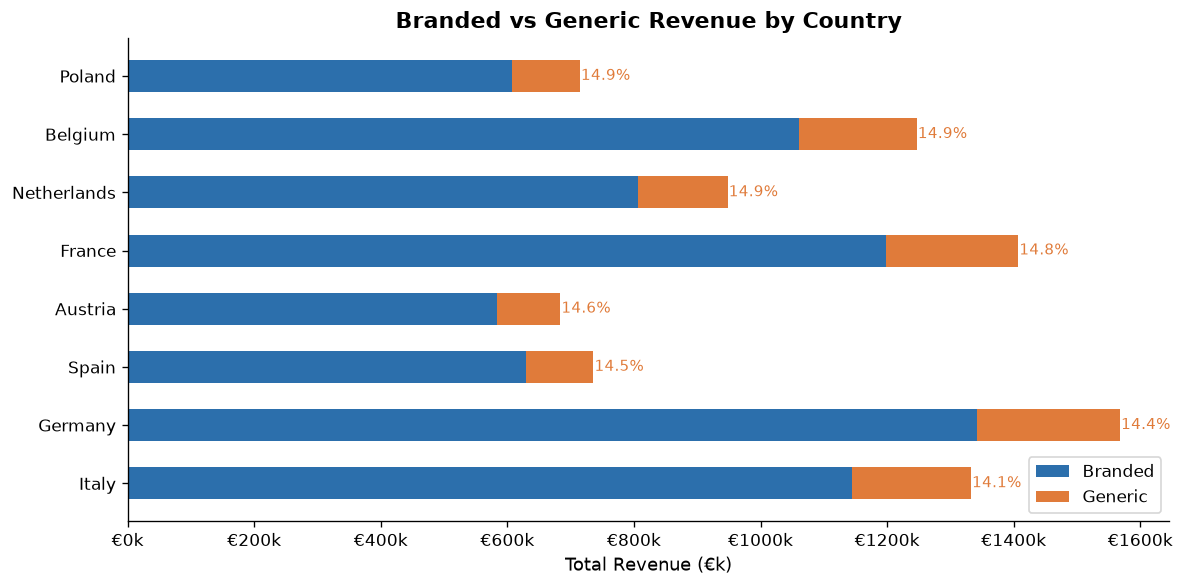

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

df_c_sorted = df_country.sort_values('generic_share_pct')

ax.barh(df_c_sorted['country'], df_c_sorted['branded_revenue'] / 1e3,
        color=BRANDED_COLOR, label='Branded', height=0.55)
ax.barh(df_c_sorted['country'], df_c_sorted['generic_revenue'] / 1e3,
        left=df_c_sorted['branded_revenue'] / 1e3,
        color=GENERIC_COLOR, label='Generic', height=0.55)

# Annotate generic share %
for i, (row) in enumerate(df_c_sorted.itertuples()):
    total = (row.branded_revenue + row.generic_revenue) / 1e3
    ax.text(total + 2, i, f'{row.generic_share_pct}%',
            va='center', fontsize=9, color=GENERIC_COLOR)

ax.set_xlabel('Total Revenue (€k)')
ax.set_title('Branded vs Generic Revenue by Country', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('outputs/04_generic_share_by_country.png', bbox_inches='tight')
plt.show()

In [10]:
query_phtype = """
SELECT
    dp.pharmacytype,
    dpr.isgeneric,
    COUNT(fs.salesid)                                       AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct,
    ROUND(
        COUNT(fs.salesid) * 100.0 /
        SUM(COUNT(fs.salesid)) OVER (PARTITION BY dp.pharmacytype),
    1) AS tx_share_within_type
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid  = dpr.productid
JOIN dim_pharmacy dp  ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.pharmacytype, dpr.isgeneric
ORDER BY dp.pharmacytype, dpr.isgeneric
"""

df_phtype = run_query(query_phtype)
df_phtype['label'] = df_phtype['isgeneric'].map({'No': 'Branded', 'Yes': 'Generic'})
print(df_phtype.to_string(index=False))
pharmacy_types = ['Urban', 'Suburban', 'Rural']


pharmacytype isgeneric  transactions  total_revenue  avg_revenue_per_tx  margin_pct  tx_share_within_type   label
       Rural        No          8584     1196039.16              139.33        28.5                  84.3 Branded
       Rural       Yes          1600      203343.32              127.09        25.6                  15.7 Generic
    Suburban        No         18869     2658345.36              140.88        28.5                  84.2 Branded
    Suburban       Yes          3534      450950.20              127.60        25.5                  15.8 Generic
       Urban        No         24849     3519201.42              141.62        28.4                  84.1 Branded
       Urban       Yes          4703      606097.85              128.87        25.4                  15.9 Generic


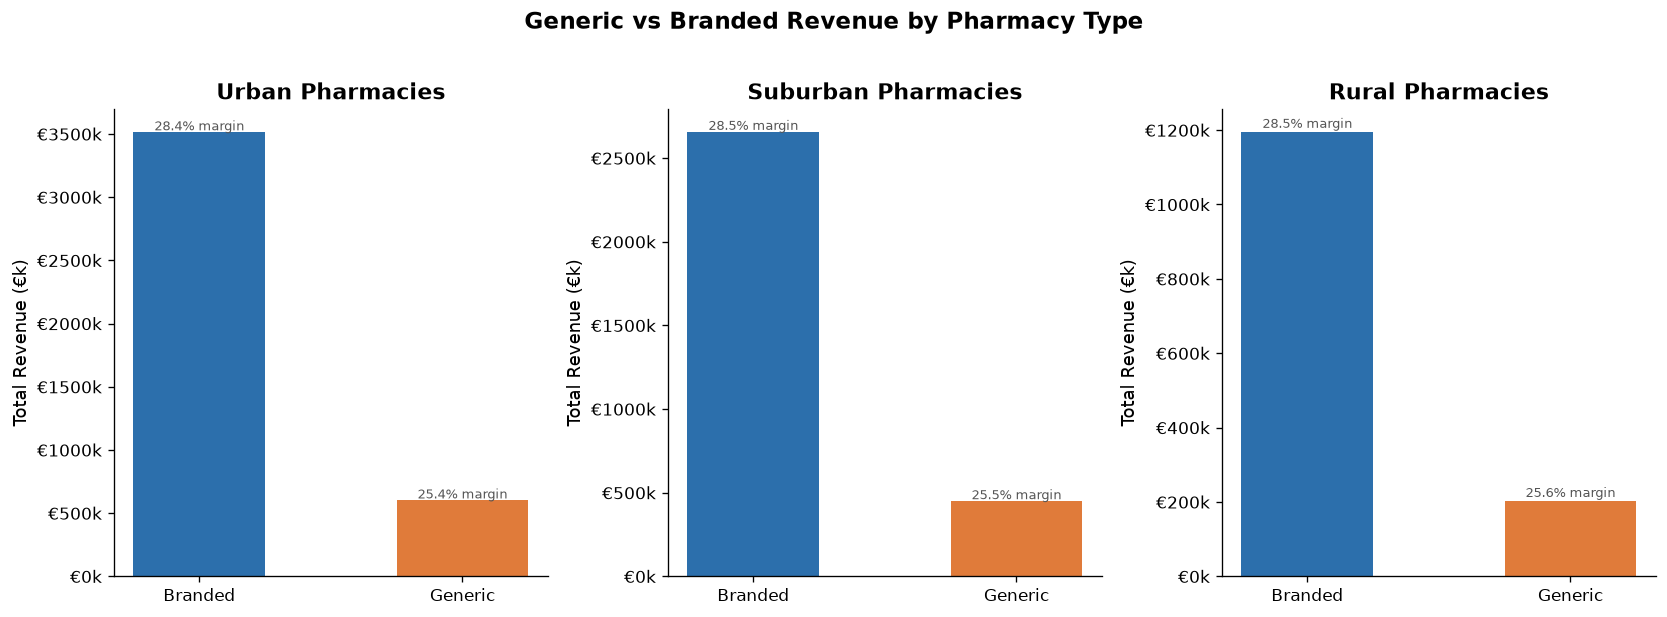

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, phtype in zip(axes, pharmacy_types):
    subset = df_phtype[df_phtype['pharmacytype'] == phtype]
    labels = subset['label'].tolist()
    revs   = subset['total_revenue'].tolist()
    colors = [BRANDED_COLOR if l == 'Branded' else GENERIC_COLOR for l in labels]

    bars = ax.bar(labels, [r / 1e3 for r in revs], color=colors, width=0.5)
    ax.set_title(f'{phtype} Pharmacies', fontweight='bold')
    ax.set_ylabel('Total Revenue (€k)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, row in zip(bars, subset.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{row.margin_pct}% margin',
            ha='center', fontsize=8, color='#555'
        )

plt.suptitle('Generic vs Branded Revenue by Pharmacy Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/05_generic_branded_by_pharmacy_type.png', bbox_inches='tight')
plt.show()

In [12]:
query_top_generic = """
SELECT
    dpr.productid,
    dpr.productname,
    dpr.category,
    dpr.brand,
    COUNT(fs.salesid)                                       AS transactions,
    SUM(fs.unitssold)                                       AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                             AS total_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
WHERE dpr.isgeneric = 'Yes'
GROUP BY dpr.productid, dpr.productname, dpr.category, dpr.brand
ORDER BY total_revenue DESC
LIMIT 10
"""

df_top_gen = run_query(query_top_generic)
print("── Top 10 generic products by revenue ──")
print(df_top_gen.to_string(index=False))
CATEGORY_COLORS = {
    'Prescription':    '#2C6FAC',
    'OTC':             '#3A9E6F',
    'Wellness':        '#E07B3A',
    'Personal Care':   '#9B5EA0',
    'Medical Devices': '#C0392B'
}

bar_colors = [CATEGORY_COLORS[c] for c in df_top_gen.sort_values('total_revenue')['category']]



── Top 10 generic products by revenue ──
productid                     productname     category      brand  transactions  total_units  total_revenue  total_margin  margin_pct
   PR0025   AntiBioX ACE Inhibitor 400 mg Prescription   AntiBioX           285         1393      107479.38      28467.88        26.5
   PR0041 OncoAssist Antidepressant 40 mg Prescription OncoAssist           322         1499      104707.51      26099.58        24.9
   PR0080         CardioPro Inhaler 10 mg Prescription  CardioPro           288         1349       80132.47      14006.22        17.5
   PR0123    OncoAssist Antibiotic 400 mg Prescription OncoAssist           267         1355       62266.22      11644.74        18.7
   PR0015           DermRx Inhaler 400 mg Prescription     DermRx           280         1353       59179.09      13852.93        23.4
   PR0020       VitaCare Vitamin C 400 mg          OTC   VitaCare           361         3308       54780.01      18278.69        33.4
   PR0218          Pa

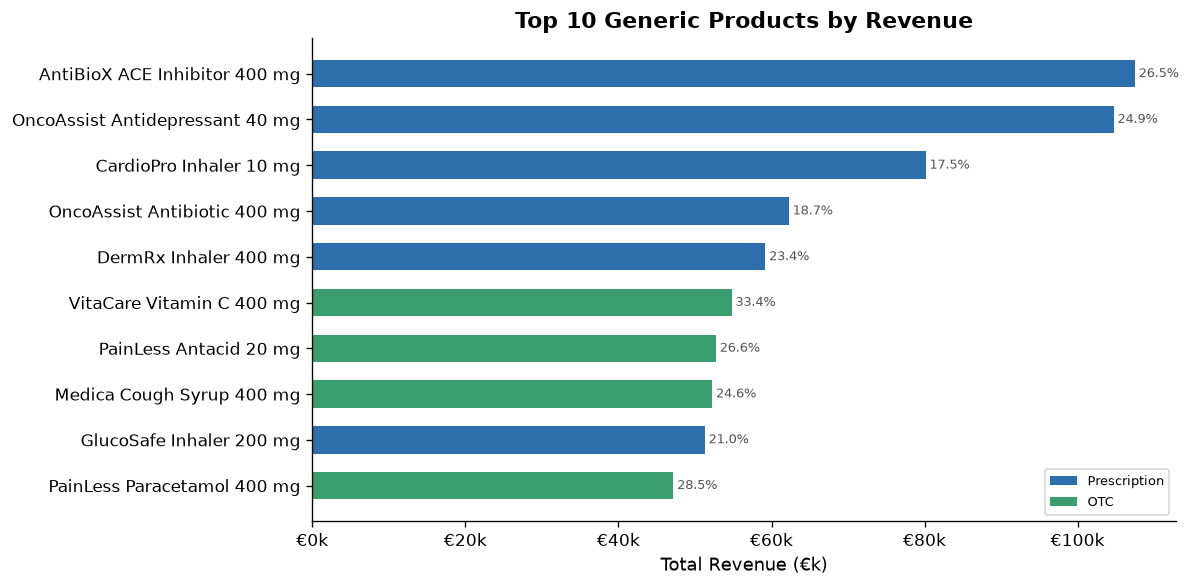

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    df_top_gen.sort_values('total_revenue')['productname'].str[:35],
    df_top_gen.sort_values('total_revenue')['total_revenue'] / 1e3,
    color=bar_colors, height=0.6
)
ax.set_xlabel('Total Revenue (€k)')
ax.set_title('Top 10 Generic Products by Revenue', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

# Annotate with margin %
for bar, row in zip(bars, df_top_gen.sort_values('total_revenue').itertuples()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{row.margin_pct}%',
        va='center', fontsize=8, color='#555'
    )

legend_elements = [Patch(facecolor=v, label=k) for k, v in CATEGORY_COLORS.items()
                   if k in df_top_gen['category'].values]
ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('outputs/06_top_generic_products.png', bbox_inches='tight')
plt.show()

In [15]:
# Overall comparison
df_overall.to_csv('../../data/processed/generic_vs_branded_overall.csv', index=False)

# By category (OTC and Prescription only)
df_cat.to_csv('../../data/processed/generic_vs_branded_by_category.csv', index=False)

# Penetration by category
df_pen.to_csv('../../data/processed/generic_penetration_by_category.csv', index=False)

# By country
df_country.to_csv('../../data/processed/generic_share_by_country.csv', index=False)

# By pharmacy type
df_phtype.to_csv('../../data/processed/generic_vs_branded_by_pharmacy_type.csv', index=False)

# Top generic products
df_top_gen.to_csv('../../data/processed/top_generic_products.csv', index=False)

print("All CSVs exported to data/processed/")
print()
print("Files created:")
print("  generic_vs_branded_overall.csv")
print("  generic_vs_branded_by_category.csv")
print("  generic_penetration_by_category.csv")
print("  generic_share_by_country.csv")
print("  generic_vs_branded_by_pharmacy_type.csv")
print("  top_generic_products.csv")

All CSVs exported to data/processed/

Files created:
  generic_vs_branded_overall.csv
  generic_vs_branded_by_category.csv
  generic_penetration_by_category.csv
  generic_share_by_country.csv
  generic_vs_branded_by_pharmacy_type.csv
  top_generic_products.csv


In [16]:
summary = """
MODULE 2 — GENERIC VS BRANDED PERFORMANCE
==========================================

OVERALL FINDINGS
----------------
- 33 generic products (15% of catalogue) vs 187 branded (85%)
- Generics represent 15.8% of transactions but only 14.6% of revenue
- Branded outperforms generic on every key metric:
    Avg revenue per tx:  €140.98 vs €128.13  (−9.1%)
    Avg margin per tx:   €40.15  vs €32.64   (−18.7%)
    Gross margin %:      28.5%   vs 25.5%    (−3.0pp)
    Revenue per unit:    €19.87  vs €16.88   (−15.0%)
- Generics have marginally higher avg units per tx (7.59 vs 7.10)
  but this does not compensate for lower prices and margin rates

CATEGORY FINDINGS
-----------------
- Generics exist ONLY in OTC (20 products, 32.8% penetration) and
  Prescription (13 products, 27.7% penetration)
- Medical Devices, Personal Care, Wellness: fully branded
- In OTC: margin % gap is negligible (29.5% branded vs 29.2% generic)
  — generics are competitively priced in OTC
- In Prescription: margin % is 21.8% branded vs 22.4% generic
  — generics have a slight margin edge within Prescription
- The overall generic margin disadvantage is a product mix effect:
  generic Prescription products pull the blended average down

GEOGRAPHIC FINDINGS
-------------------
- Generic revenue share is consistent across all 8 countries (14.1–14.9%)
- No country shows a meaningful preference for or against generics
- Generic adoption appears driven by product availability, not geography

PHARMACY TYPE FINDINGS
----------------------
- Branded margin advantage (28.5% vs 25.5%) is consistent across
  Urban, Suburban, and Rural pharmacy types
- Generic transaction share is consistent within each pharmacy type (~15–16%)

CHARTS SAVED
------------
  outputs/01_generic_vs_branded_overall.png
  outputs/02_generic_branded_by_category.png
  outputs/03_generic_penetration_by_category.png
  outputs/04_generic_share_by_country.png
  outputs/05_generic_branded_by_pharmacy_type.png
  outputs/06_top_generic_products.png

CSVs EXPORTED
-------------
  data/processed/generic_vs_branded_overall.csv
  data/processed/generic_vs_branded_by_category.csv
  data/processed/generic_penetration_by_category.csv
  data/processed/generic_share_by_country.csv
  data/processed/generic_vs_branded_by_pharmacy_type.csv
  data/processed/top_generic_products.csv
"""

print(summary)


MODULE 2 — GENERIC VS BRANDED PERFORMANCE

OVERALL FINDINGS
----------------
- 33 generic products (15% of catalogue) vs 187 branded (85%)
- Generics represent 15.8% of transactions but only 14.6% of revenue
- Branded outperforms generic on every key metric:
    Avg revenue per tx:  €140.98 vs €128.13  (−9.1%)
    Avg margin per tx:   €40.15  vs €32.64   (−18.7%)
    Gross margin %:      28.5%   vs 25.5%    (−3.0pp)
    Revenue per unit:    €19.87  vs €16.88   (−15.0%)
- Generics have marginally higher avg units per tx (7.59 vs 7.10)
  but this does not compensate for lower prices and margin rates

CATEGORY FINDINGS
-----------------
- Generics exist ONLY in OTC (20 products, 32.8% penetration) and
  Prescription (13 products, 27.7% penetration)
- Medical Devices, Personal Care, Wellness: fully branded
- In OTC: margin % gap is negligible (29.5% branded vs 29.2% generic)
  — generics are competitively priced in OTC
- In Prescription: margin % is 21.8% branded vs 22.4% generic
  — gene